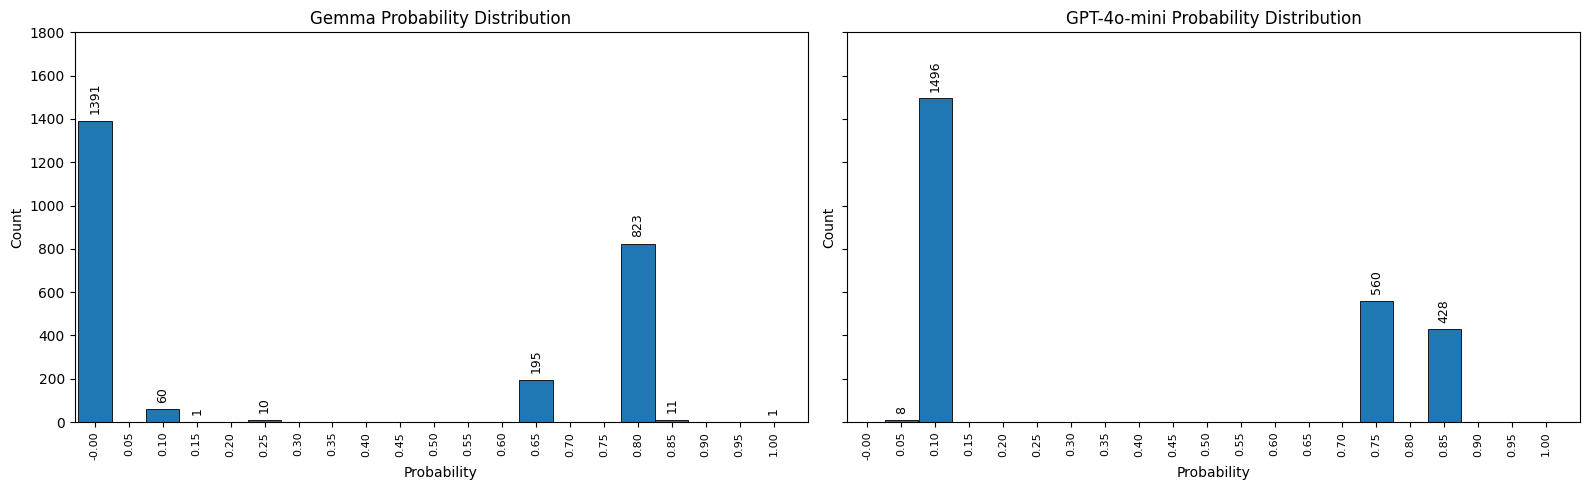

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

input_csv = Path("/users/PCS0229/imankhazrak/EHR-Agentic-AI/data/outputs/case_studies/model_comparison_gemma_coagent_vs_gpt4omini_fewshot.csv")
output_dir = Path("/users/PCS0229/imankhazrak/EHR-Agentic-AI/data/outputs/case_studies/analysis")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(input_csv)

required_cols = ["case_id", "true_label", "gpt_prob", "gemma_prob"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")


def plot_hist_on_axis(ax, series: pd.Series, title: str) -> None:
    counts, bin_edges, patches = ax.hist(
        series,
        bins=21,
        range=(-0.025, 1.025),
        rwidth=0.98,
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xlabel("Probability")
    ax.set_ylabel("Count")
    ax.set_ylim(0, 1800)
    ax.set_title(title)

    # Put xticks at bar centers so 0.00 and 1.00 are centered on bars.
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.set_xticks(bin_centers)
    ax.set_xticklabels([f"{x:.2f}" for x in bin_centers], rotation=90, fontsize=8)
    ax.set_xlim(-0.03, 1.05)

    for count, patch in zip(counts, patches):
        if count <= 0:
            continue
        x = patch.get_x() + patch.get_width() / 2.0
        y = patch.get_height()
        ax.text(x, y + 30, f"{int(count)}", ha="center", va="bottom", fontsize=9, rotation=90)


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

plot_hist_on_axis(axes[0], df["gemma_prob"], "Gemma Probability Distribution")
plot_hist_on_axis(axes[1], df["gpt_prob"], "GPT-4o-mini Probability Distribution")

plt.tight_layout()
plt.show()
